[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026-CS1090A-public/blob/sec01-2026b/sec01/cs1090a_sec01_student.ipynb)

> **On Colab, do `File → Save a copy in Drive` before you start.** This notebook opens from GitHub, so you can type in it and run it right away — but nothing is being saved anywhere. Close the tab and the work is gone. Saving a copy first gives you one that persists in your own Drive.

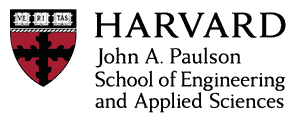

### CS1090A Introduction to Data Science

## Section 1: Web Scraping, Caching and Reproducibility

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas and Kevin Rader<br/>
**Preceptor**: Chris Gumb

<hr style='height:2px'>

In [ ]:
# Provided — setup. On Colab this fetches the data files this notebook needs.
# Everywhere else it does nothing except confirm they are already here.
#
# Generated at publish time; see utils/inject_colab_bootstrap.py. Editing this cell
# in the public repo is wasted work -- the next publish overwrites it.
import os
import shutil
import subprocess
import sys

_REPO    = "https://github.com/Harvard-CS1090/2026-CS1090A-public"
_REF     = "sec01-2026b"
_SECTION = "sec01"

_DIRNAME = _REPO.rstrip("/").split("/")[-1].removesuffix(".git")

if os.path.isdir("data"):
    print(f"data/ is present -- nothing to fetch.")
elif "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook reads its inputs from a data/ folder, which is not here.\n"
        "It does not fetch them from the live web -- that is deliberate, and Part 1\n"
        "explains why.\n\n"
        "Fix: get the whole folder, not just the notebook --\n"
        f"    git clone --branch {_REF} {_REPO}\n"
        f"    cd {_DIRNAME}/{_SECTION}\n"
        "    jupyter lab\n\n"
        "Then open this notebook from in there. (On Colab, this cell fetches it for you.)"
    )
else:
    print("Colab detected, no data/ -- fetching it once...")
    _tmp = "/content/_cs1090a_materials"
    if not os.path.isdir(_tmp):
        _r = subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", _REF, _REPO, _tmp],
            capture_output=True, text=True,
        )
        if _r.returncode != 0:
            raise RuntimeError(
                f"Could not download the data files from {_REPO} (ref {_REF}).\n\n"
                f"git said: {_r.stderr.strip().splitlines()[-1] if _r.stderr.strip() else 'no output'}\n\n"
                "This is not something you did wrong. Post on Ed with this message and\n"
                "a TF will sort it out; meanwhile the section notebook will not run here."
            )
    _dir = os.path.join(_tmp, _SECTION)
    _src = os.path.join(_dir, "data")
    if not os.path.isdir(_src):
        raise RuntimeError(
            f"Cloned {_REPO} at {_REF} but found no {_SECTION}/data in it.\n"
            "The published bundle is incomplete -- please report this on Ed."
        )
    shutil.copytree(_src, "data")

    # Sibling modules too, not just data/. Section 1 does `from section_helpers import
    # Recorded`; fetching data/ alone leaves that import failing three cells later,
    # which reads as "the notebook is broken" rather than "setup was incomplete".
    _mods = [f for f in os.listdir(_dir) if f.endswith(".py")]
    for _m in _mods:
        shutil.copy(os.path.join(_dir, _m), _m)

    print(f"data/ ready ({len(os.listdir('data'))} entries)"
          + (f", plus {', '.join(sorted(_mods))}." if _mods else "."))


<div style="background:#E8F1FF; border-left:6px solid #2563EB; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🎯 Objectives</div>
<div>
By the end you should be able to:
<ul>
<li>fetch a page with <code>requests</code> and read its status code;</li>
<li>cache it to disk so the fetch happens once;</li>
<li>pull records out of HTML with BeautifulSoup;</li>
<li>save a list-of-dicts as JSON — and say why that file is the dataset;</li>
<li>say what is reproducible, what is brittle, and when not to scrape at all.</li>
</ul>
</div>
</div>

## How to read this notebook

<table style="border-collapse:separate; border-spacing:0 4px;">
<tr><td style="background:#FFF7CC; border-left:6px solid #D97706; padding:6px 12px; white-space:nowrap;"><strong>🤔 Predict</strong></td><td style="padding:6px 12px;">Commit to an answer <em>before</em> running the code.</td></tr>
<tr><td style="background:#E9F8EE; border-left:6px solid #16A34A; padding:6px 12px; white-space:nowrap;"><strong>🏋️ Exercise</strong></td><td style="padding:6px 12px;">Fill in the blanks. Look for <code># your code here</code>.</td></tr>
<tr><td style="background:#FDECEC; border-left:6px solid #DC2626; padding:6px 12px; white-space:nowrap;"><strong>💬 Discuss</strong></td><td style="padding:6px 12px;">Stop running cells. Talk to a partner.</td></tr>
<tr><td style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:6px 12px; white-space:nowrap;"><strong>⭐ Insight</strong></td><td style="padding:6px 12px;">The point of what you just did.</td></tr>
<tr><td style="background:#F3F4F6; border-left:6px solid #4B5563; padding:6px 12px; white-space:nowrap;"><strong>🧠 Takeaways</strong></td><td style="padding:6px 12px;">What to carry out of the room.</td></tr>
</table>

Cells run top to bottom. The **Appendix** is for afterwards — nobody is expected to reach it.

## The question

> *Which laureates have won more than one Nobel Prize?*

[nobelprize.org](https://www.nobelprize.org/prizes/lists/all-nobel-prizes/all/) lists every
prize since 1901, one card each. It will show you any single prize. It will not tell you
which names repeat — that is a question about *all the cards at once*.

So we turn the page into a file we can compute on.

In [ ]:
# Provided — run this first.
from collections import Counter, defaultdict
import json
import os
import re
import time

from bs4 import BeautifulSoup
from IPython.display import HTML
import requests

from section_helpers import Recorded   # a saved response that acts like a live one

DATA = "data"
print("ready")

## Part 1. Get the page

[`requests`](https://requests.readthedocs.io/en/latest/) is the standard library for
fetching things over HTTP. We build up its four moving parts one at a time.

First, the URL we want.

In [ ]:
all_prizes_url = 'https://www.nobelprize.org/prizes/lists/all-nobel-prizes/all/'
all_prizes_url

`requests` sends a **User-Agent** header identifying the client. Left alone it says
`python-requests`.

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — what does that URL return?</div>
<div>
You call <code>requests.get(all_prizes_url)</code> with no headers, so you announce
yourself as <code>python-requests</code>. What comes back?

<ol style="list-style:none; padding-left:1.2em;">
<li><strong>A.</strong> 200 — the page</li>
<li><strong>B.</strong> 403 — refused</li>
<li><strong>C.</strong> 404 — no such page</li>
</ol>
</div>
</div>

Here is that request, saved from a real run:

In [ ]:
bot = Recorded("nobel_403_default_ua")
bot

The status code lives on `.status_code`.

In [ ]:
bot.status_code

Now the same URL with a browser's User-Agent:

In [ ]:
browser = Recorded("nobel_200_browser_ua")
browser.status_code

Two digits tell you most of it: **2xx** worked, **3xx** moved, **4xx** you got it wrong,
**5xx** the server did.

The page content is in `.text`, one long string. Peek at the front:

In [ ]:
browser.text[:200]

How long is it?

In [ ]:
len(browser.text)

### Our own identity

We will not send that browser string — it is not true. A descriptive one says who we are
and how to reach us:

In [ ]:
HEADERS = {
    "User-Agent": "CS1090A-course-exercise/2026 (Harvard; cs1090a-staff@harvard.edu)"
}
HEADERS

### Fetch once, cache to disk

Re-running a fetch hits someone's server for bytes you already have — and next year the
page will have changed, so your result stops reproducing.

The rule: **fetch only if there is no local copy.** `os.path.isfile` is the test.

In [ ]:
html_file = f"{DATA}/all_prizes.html"
os.path.isfile(html_file)

Writing is two lines — `open(path, "w", encoding="utf-8")` then `.write(text)`:

```python
with open(path, "w", encoding="utf-8") as f:      # "w" = write; the default is read
    f.write(text)
```

**Always pass `encoding="utf-8"` when you open a text file.** If you leave it out, Python
uses whatever text encoding your operating system happens to default to — UTF-8 on macOS
and Linux, but usually cp1252 on Windows. The Nobel page has names like *Röntgen* and
*Néel* in it, and cp1252 cannot read the bytes that UTF-8 uses to store those letters, so
the same line of code that works on one laptop fails on another with a
`UnicodeDecodeError`. Naming the encoding yourself removes the difference: the file is
written and read the same way on every machine.

Reading the cached page back:

In [ ]:
with open(html_file, encoding="utf-8") as f:
    html = f.read()

len(html)

### Checking that a downloaded page is really the page you asked for

Suppose the site answers with a `403` error page and your code writes that error page
into `all_prizes.html`. The file now exists, so the next time you run the notebook the
`os.path.isfile` test takes the "we already have it" branch and never re-fetches. Nothing
appears to be wrong until Part 3 looks for prize cards in that file and finds none, about
thirty cells later.

The three checks below prevent this by refusing to save a response that is not the page
you asked for.

**One** — `raise_for_status()` turns an error status into an exception:

In [ ]:
try:
    bot.raise_for_status()
except requests.HTTPError as e:
    print("caught:", e)

**Two** — size. The real page is ~670,000 characters; an error page is tiny:

In [ ]:
len(bot.text), len(browser.text)

**Three** — shape. Only the real page contains the string `card-prize`:

In [ ]:
"card-prize" in bot.text, "card-prize" in browser.text

Those three, in one provided function:

In [ ]:
# Provided — the three checks above, together.
def looks_real(response, min_chars=100_000, marker="card-prize"):
    """Raise if `response` is not the page we wanted."""
    response.raise_for_status()
    if len(response.text) < min_chars:
        raise ValueError(f"only {len(response.text):,} characters")
    if marker not in response.text:
        raise ValueError(f"no {marker!r} in the body")


try:
    looks_real(bot)                    # the 403 we saw earlier
except requests.HTTPError as e:
    print("rejected:", e)

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 1: the guarded fetch (5 min)</div>
<div>
Now assemble it. Four blanks:

<ol>
<li>the <code>os.path.isfile</code> test — run above</li>
<li>the <code>requests.get(url, headers=HEADERS)</code> call — the one line here you have
    <em>not</em> run, because every response so far has been a recording. Its full form is
    written out in the cell comment</li>
<li>the <code>looks_real</code> check, <em>before</em> anything is written — run above</li>
<li><code>f.write(...)</code> — run above</li>
</ol>

<strong>Note:</strong> blank 2 will not run today, because
<code>data/all_prizes.html</code> is already on your disk and the <code>isfile</code> test
takes the other branch. That is worth noticing: on a machine that does <em>not</em> have
the file, blank 2 is the only line in this function that uses the network.
</div>
</div>

In [ ]:
def fetch_to_cache(url, path):
    """Fetch `url` to `path`, but only if `path` is missing and the response looks right."""
    os.makedirs(os.path.dirname(path), exist_ok=True)     # provided: HW1 needs this too
    # your code here
    if ... :                                  # 1. do we already have it?
        print(f"cached: {path}")
    else:
        response = requests.get(url, headers=..., timeout=30)   # 2. ask for it
        ...                                   # 3. check it before trusting it
        with open(path, "w", encoding="utf-8") as f:
            f.write(...)                      # 4. save it
        print(f"fetched: {path}")

    with open(path, encoding="utf-8") as f:                       # either way, read from disk
        return f.read()

In [ ]:
# Provided — run yours. It should say "cached", not "fetched".
html = fetch_to_cache(all_prizes_url, html_file)
len(html)

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 1 (2 min)</div>
<div>
<strong>With a partner:</strong> a classmate's version skips step 3. They run it on a
day when the site returns an error, and that error page gets written to
<code>all_prizes.html</code>. When do they find out something is wrong?

<strong>Whole room:</strong> the marker check looks for <code>card-prize</code>. What kind
of site change slips straight past it?
</div>
</div>

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight</div>
<div>
<strong>Fetch once. Validate before you save. Read from disk forever after.</strong>

Your results now depend on a file you can point at, not on what a server felt like
returning this morning.
</div>
</div>

## Part 2. Find the data in the page

We have 670,000 characters of HTML. Somewhere in there are ~700 prizes.

HTML is a **tree** — tags nested in tags. Each prize looks like this:

```html
<div class="card-prize">
  <h3><a href="/prizes/physics/2025/">Nobel Prize in Physics 2025</a></h3>
  <blockquote class="border-blue">"for the discovery of ..."</blockquote>
</div>
```

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — inspect the page (2 min)</div>
<div>
Open <a href="https://www.nobelprize.org/prizes/lists/all-nobel-prizes/all/">the page</a>,
right-click the citation text under any prize, and choose <em>Inspect</em>.

<ol>
<li>What is that <code>&lt;blockquote&gt;</code>'s <code>class</code>?</li>
<li>Which is more likely to still work next year — code that looks for that class name,
    or code that looks for "the blockquote inside each prize card"?</li>
</ol>
</div>
</div>

670,000 characters of nested tags. You could regex that string — fine for **text**
(appendix A7), but finding *structure* that way re-implements an HTML parser one edge case
at a time.

**Use a parser to find elements; use string methods on the text it hands you.**

## Part 3. Parse the tree with BeautifulSoup

BeautifulSoup turns that string into a tree you can search. Again, one call at a time.

Parse once. `soup` is the root of the tree:

In [ ]:
soup = BeautifulSoup(html, 'lxml')
type(soup)

`select` returns **all** matches as a list. A leading `.` means *class*:

In [ ]:
cards = soup.select('.card-prize')
len(cards)

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Quick one — 90 seconds</div>
<div>
<code>cards</code> is a plain list, so it indexes like one. Print the <code>&lt;h3&gt;</code>
text of the <strong>last</strong> prize on the page, stripped of whitespace.
</div>
</div>

In [ ]:
# your code here
print(cards[...].h3.text.strip())


### Four fields out of one card

Naming a tag as an attribute gets the first one of that kind. `.text` gives the string
inside, but HTML leaves whitespace everywhere — so `get_text(strip=True)` does both at
once. **That is the call HW1 uses.**

In [ ]:
card = cards[0]
card.h3.text, card.h3.get_text(strip=True)

Title and year are welded together. The last five characters are `' 2025'`, so `[:-5]`
drops them. And `.split()` breaks a string on whitespace, which makes the year the
**last** token — index `[-1]`:

In [ ]:
t = card.h3.get_text(strip=True)
t[:-5], t.split()

The citation is the card's `<blockquote>`:

In [ ]:
card.blockquote.get_text(strip=True)[:80]

`select` works on a **node**, not just the whole soup — and a selector with a space means
"anywhere inside". Both matter in HW1, where each listing is dug out of a container:

In [ ]:
card.select('h3 a')

### A shape you will meet in HW1

Not every field sits inside the node you selected. HW1's listings carry their **date on an
ancestor**, and pack several fields into one comma-separated string where the middle ones
may be missing. Both moves, on a miniature:

In [ ]:
# Provided — a miniature in HW1's shape.
mini = BeautifulSoup("""
<div id="2026-07-11">
  <button><div class="flex-col">
    <p>Monty Python and the Holy Grail</p>
    <p>1975, Adventure, 1h 31m</p>
  </div></button>
</div>""", "lxml")

listing = mini.select_one("button .flex-col")     # descendant selector, as in HW1
listing.select("p")[0].get_text(strip=True)

**Idiom 1 — walk up.** The date is on an *ancestor*, not inside the listing.
`find_parent(id=True)` climbs to the nearest ancestor that has an `id`, and you keep
climbing until the `id` looks like a date:

In [ ]:
node = listing.find_parent(id=True)
while node and not re.match(r"^\d{4}-\d{2}-\d{2}$", node.get("id", "")):
    node = node.find_parent(id=True)

screen_date = node["id"] if node else None        # None if we ran out of ancestors
screen_date

**Idiom 2 — one field, several values, some missing.** `"1975, Adventure, 1h 31m"` splits
into three; but either middle part can be absent, and `"1975, 1h 31m"` must not put a
runtime in the genre slot. Position alone cannot tell you — you have to look at the content:

In [ ]:
def looks_like_runtime(s):
    s = s.lower()
    return any(ch.isdigit() for ch in s) and ("h" in s or "m" in s)


for raw in ["1975, Adventure, 1h 31m", "1975, Adventure", "1975, 1h 31m"]:
    parts = [x.strip() for x in raw.split(",")]
    year, genre, runtime = int(parts[0]), None, None
    if len(parts) >= 3:
        genre, runtime = parts[1], parts[2]
    elif len(parts) == 2:
        if looks_like_runtime(parts[1]):
            runtime = parts[1]
        else:
            genre = parts[1]
    print(f"{raw:<26} -> year={year} genre={genre!r} runtime={runtime!r}")

### Laureates: several per prize

Each laureate is an `<a>` tag; laureate links carry a `class` and the card's other links
do not.

`tag.get('class')` returns a **list** of class names, or `None` — so `if a.get('class')`
means "has any class at all". **HW1 filters listings exactly this way.** It is a weak thing
to depend on; Checkpoint 2 returns to it.

In [ ]:
[a.get('class') for a in card.find_all('a')][:6]

`.text` gives the name, `.get('href')` reads an attribute. Names first:

In [ ]:
[a.get_text(strip=True) for a in card.find_all('a') if a.get('class')]

`.get('href')` reads an attribute off the tag — the links:

In [ ]:
[a.get('href') for a in card.find_all('a') if a.get('class')]

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Quick one — 90 seconds</div>
<div>
Same comprehension, but collect <code>[name, url]</code> <strong>pairs</strong>.

A list rather than a tuple, deliberately: this record is headed for a JSON file, and JSON
has no tuple type.
</div>
</div>

In [ ]:
links = [a for a in card.find_all('a') if a.get('class')]

# your code here
pairs = [[..., ...] for a in links]

pairs

### Compose

Those lines, wrapped so we can reuse them. `get_title` is done for you:

In [ ]:
# Provided — the pattern to copy.
def get_title(card):
    return card.h3.get_text(strip=True)[:-5]


get_title(card)

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 2: two more extractors (3 min)</div>
<div>
One blank each, and every line you need is in a cell above. <code>get_desc</code> is done
for you — it is the same shape as <code>get_title</code>.
</div>
</div>

In [ ]:
def get_year(card):
    # your code here
    return int(card.h3.get_text(strip=True).split()[...])   # which token is the year?


def get_desc(card):                       # provided -- same shape as get_title
    return card.blockquote.get_text(strip=True)


def get_laureates(card):
    # your code here
    return [[..., ...]
            for a in card.find_all('a') if a.get('class')]


In [ ]:
# Provided — check them on two cards: one laureate, and three.
solo = next(c for c in cards if len(get_laureates(c)) == 1)
trio = next(c for c in cards if len(get_laureates(c)) == 3)

for label, c in (("one", solo), ("three", trio)):
    assert isinstance(get_year(c), int), f"[{label}] get_year must return an int"
    assert not get_title(c).endswith(str(get_year(c))), f"[{label}] year still in title"
    assert get_desc(c) and not get_desc(c).startswith(" "), f"[{label}] desc unstripped"
    print(f"[{label}] {get_year(c)}  {get_title(c)}")
    for n, u in get_laureates(c):
        print("      ", n)
print("\nAll checks passed.")

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 2 (2 min)</div>
<div>
<strong>With a partner:</strong> <code>get_title</code> chops five characters and works on
all 682 cards today. What would have to change for it to start returning <em>silently
wrong</em> titles rather than raising?

<strong>Whole room:</strong> without its zero-container check, your parser would have
returned <code>0 records, 0 failed</code> from the redesigned page — no exception, no
complaint. Why is that worse than the error it raised instead?
</div>
</div>

## Part 4. From tags to a dataset

Four functions that work on one card. Run them over all 682 and you have a dataset:
a **list of dictionaries**, one per prize. That is the shape `pandas` takes in
Lecture 2, and the shape HW1 asks for.

`append` adds to a list, so a loop builds the whole thing. Three cards' worth:

In [ ]:
demo = []
for c in cards[:3]:
    demo.append({"title": get_title(c), "year": get_year(c)})

demo

One wrinkle: in some war years no prize was given. Those cards have a citation saying so
and no laureates — they are not prizes, and they will pollute every count.

In [ ]:
sum(1 for c in cards if "No Nobel Prize was awarded" in get_desc(c))

### One parser, many pages

HW1 runs your parser over a live page **and ~20 archived snapshots**, so write a
**function of an HTML string**, not a loop in a cell.

And HW1 grades this: **one malformed listing must not kill the parse.** `try`/`except`
each record, keep going, and *count* what you lost.

`try`/`except` around one value, so the shape is familiar:

In [ ]:
for value in ["1975", "not-a-year"]:
    try:
        print(int(value))
    except ValueError:
        print(f"skipped {value!r}")

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 3: write parse_page (6 min)</div>
<div>
Four blanks. It takes <strong>an HTML string</strong> — not a soup, not a list of cards —
because Part 5 and HW1 both hand it a different page.

<ol>
<li>soup the html and select the cards</li>
<li>build one record from the four extractors</li>
<li>count a failure instead of crashing</li>
<li>return the records (the count is <em>printed</em>, not returned — so that
    <code>all_records.extend(parse_page(html))</code> works, which is what HW1 Q3 does
    across ~20 snapshots)</li>
</ol>

The zero-container check is written for you. Checkpoint 2 is about why it has to be there.
</div>
</div>

In [ ]:
def parse_page(html, label="page"):
    """HTML string -> list of prize records. Prints how many listings failed.

    Returns records only -- so `all_records.extend(parse_page(html))` works, which is
    what HW1 Q3 does across ~20 snapshots. The failure count is *reported*, not returned.
    """
    # your code here
    cards = BeautifulSoup(html, "lxml").select(...)     # 1. same selector as before
    if not cards:
        raise ValueError("no .card-prize nodes -- has the page structure changed?")
    records, failed = [], 0
    for c in cards:
        try:
            desc = get_desc(c)
            if "No Nobel Prize was awarded" in desc:
                continue
            records.append({
                "title": ...,                           # 2. the four extractors
                "year": ...,
                "laureates": ...,
                "description": desc,
            })
        except Exception:
            ...                                         # 3. count it, do not crash
    print(f"{label}: {len(records)} records, {failed} failed")
    return ...                                          # 4. the records


In [ ]:
# Provided — run yours, then hand it a page it was never written for.
parsed_prizes = parse_page(html, label="today's page")

try:
    parse_page("<html><body><p>site redesigned</p></body></html>")
except ValueError as e:
    print(f"redesigned page: refused loudly -- {e}")

assert parsed_prizes, "no records -- did the loop body run?"
assert set(parsed_prizes[0]) == {"title", "year", "laureates", "description"}
assert not any("No Nobel Prize" in p["description"] for p in parsed_prizes)
print("OK")

### Answering the question we opened with

*Which laureates have won more than one Nobel Prize?* Each record holds a list of laureates,
so first flatten them. `extend` adds the **items** of a list; `append` would add the list
itself:

In [ ]:
demo = []
demo.extend([("a", 1), ("b", 2)])
demo

### Saving the parsed data so you can reload it without re-scraping

Every variable you have built so far exists only in the kernel's memory. Restart the
kernel and all of it is gone, and getting it back means running the whole notebook again.
Writing the data to a file avoids that: `json.dump` writes a Python object to disk, and
`json.load` reads it back in a later session.

`json.dump(obj, f)` writes an object to an open file; `json.load(f)` reads it back:

```python
with open(path, "w", encoding="utf-8") as f:
    json.dump(obj, f, indent=1)
with open(path, encoding="utf-8") as f:
    obj = json.load(f)
```

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 4: save it, and prove it survived (4 min)</div>
<div>
Three blanks: dump <code>parsed_prizes</code>, load it back, and prove nothing changed on
the way. No guard here — we want your code to actually run.
</div>
</div>

In [ ]:
prizes_file = f"{DATA}/nobel_prizes.json"

with open(prizes_file, "w", encoding="utf-8") as f:
    # your code here
    json.dump(..., f, indent=1)           # which object is the dataset?

with open(prizes_file, encoding="utf-8") as f:
    reloaded = ...

print(f"{os.path.getsize(prizes_file):,} bytes, {len(reloaded)} records")
assert reloaded == parsed_prizes, "the round trip changed something!"
print("identical after a round trip through disk")

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight</div>
<div>
That file <em>is</em> your dataset. Anyone holding it reproduces every number here without
the network, without your kernel, and without nobelprize.org's cooperation — which is what
<code>parsed_prizes</code> sitting in RAM can never give anyone else.

Notice this notebook now makes <strong>zero</strong> network requests.
</div>
</div>

## Part 5. Will it still run next year?

The cache makes *today* reproducible. It says nothing about the site changing underneath
you. We can test that: the Internet Archive has been photographing this page for years,
and we have a capture from September 2024 — two years of prizes ago.

The Internet Archive has a small JSON API. Pass it a page and a date, as query parameters:

```python
requests.get(
    "https://archive.org/wayback/available",
    params={"url": "nobelprize.org/prizes/lists/all-nobel-prizes/all/",
            "timestamp": "20240101"},
)
```

`params=` builds the query string and URL-encodes it for you. **HW1 Q3 needs this exact
call.** Its reply, recorded:

In [ ]:
wb = Recorded("wayback_availability")
wb.status_code

`.json()` parses a JSON body into Python dicts and lists — no BeautifulSoup needed:

In [ ]:
info = wb.json()
info

It is nested, so you index down into it one key at a time:

In [ ]:
info["archived_snapshots"]

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 5: pin the snapshot (4 min)</div>
<div>
Three blanks. From <code>info</code>, dig out the <strong>closest</strong> snapshot, then
take its <code>url</code> and its <code>timestamp</code>.

The timestamp is <code>YYYYMMDDhhmmss</code> — the first 8 characters are the date, which
is how our saved file got its name.
</div>
</div>

In [ ]:
# your code here
closest = info["archived_snapshots"][...]
snap_url = closest[...]
stamp = closest[...]

snap_file = f"{DATA}/snapshot_{stamp[:8]}.html"
print(snap_url)
print("-> saved as", snap_file)

That URL returns the same bytes forever — unlike the live page. We fetched it once, months
ago, through the very same guard you wrote in Part 1:

In [ ]:
snap_html = fetch_to_cache(snap_url, snap_file)
len(snap_html)

And now the payoff for writing a **function of an HTML string**: the same parser, no
changes, on a page from two years ago. This is precisely the move HW1 Q3 asks for over
~20 snapshots.

In [ ]:
snap_prizes = parse_page(snap_html, label="2024 snapshot")

print(f"latest year -- snapshot {max(p['year'] for p in snap_prizes)}, "
      f"today {max(p['year'] for p in parsed_prizes)}")

new = ({n for p in parsed_prizes for n, _ in p["laureates"]}
       - {n for p in snap_prizes for n, _ in p["laureates"]})
print(f"\n{len(new)} laureates exist today who did not in the 2024 capture.")

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 3 (2 min)</div>
<div>
<strong>With a partner:</strong> you published "there have been <em>N</em> Nobel Prizes"
last year, with a live-fetch script attached. Someone re-runs it today and gets a different
number. Is your report wrong?

<strong>Whole room:</strong> which files would someone need to reproduce this notebook
exactly — and which of them must never be refreshed?
</div>
</div>

## Part 6. Should you have scraped at all?

Back to that 403. Before you write any of this, a practitioner checks one thing — and here
is what they would have found:

In [ ]:
print(Recorded("nobel_api_sample").text[:400])

That is the same data, from the Nobel Foundation's own free, documented, no-key
[REST API](https://nobelprize.readme.io/) — `requests.get(url).json()`, no parsing, no
class names to break.

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 4 (2 min)</div>
<div>
<strong>With a partner, before reading on:</strong> we scraped a site that publishes this
API and that refuses default clients. Was that defensible? What would you check first at a
job, before your first <code>requests.get</code>?

<strong>Whole room:</strong> our header versus the browser string in the Part 1 recording —
both one line of code. What is the difference?
</div>
</div>

<div style="background:#F3F4F6; border-left:6px solid #4B5563; padding:14px 18px; margin:16px 0; border-radius:6px;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🧠 Takeaways</div>
<div>
<ol>
<li><strong>Download each page once, check the response, and only then save it to
    disk.</strong> If you save a response without checking it first, an error page can end
    up in your cache, and every later run reads that file instead of re-fetching. The
    notebook then produces a wrong answer rather than an error message.</li>
<li><strong>Use BeautifulSoup's tree methods rather than regular expressions on raw
    HTML.</strong> HTML tags nest inside one another, and a regular expression cannot keep
    track of that nesting, so a pattern that works on today's page breaks as soon as a tag
    gains an attribute or an extra wrapper <code>&lt;div&gt;</code>. Once BeautifulSoup has
    handed you the text inside a tag, using a regular expression on <em>that</em> string is
    fine.</li>
<li><strong>Write your parsed data to a file, and treat that file as the
    dataset.</strong> A result that exists only in the kernel's memory disappears when the
    kernel restarts, and nobody else can reproduce it. A result saved to disk can be
    reloaded by you or by anyone you send it to, without scraping the site again.</li>
<li><strong>Look for an official API or a bulk download before you scrape.</strong> Try
    them in that order — a documented API first, then a published data file, then scraping
    — and if none of those exists and the site's terms of use forbid scraping, the answer
    is to not collect the data.</li>
</ol>

<strong>Exit ticket:</strong> A colleague sends you a scraping notebook that runs clean and
produces a table. Name the two things you would check first to decide whether you believe it.
</div>
</div>

## Appendix — for afterwards, and for HW1

Not expected during section.

**A6–A10 are the HW1 pieces that would not fit the hour** — encoding, throttling, many
snapshots, combining them into one dataset, and regex. They are complete worked code, not
exercises, because you will meet them alone. A1–A3 are optional practice; A4–A5 are the
narrative payoff and `defaultdict`. `HW1_COVERAGE.md` maps each to a question.

### A1. What are all the distinct prize titles?


In [ ]:
# your code here
unique_prizes = sorted({... for p in parsed_prizes})

unique_prizes

### A2. When was the Economics prize added?


In [ ]:
# your code here
econ = [... for p in parsed_prizes if ...]
print(min(econ), len(econ))


### A3. Laureates per year — a first plot


In [ ]:
import matplotlib.pyplot as plt

# your code here
per_year = defaultdict(list)
for p in parsed_prizes:
    for name, _ in p["laureates"]:
        per_year[...].append(name)

years = sorted(per_year)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(years, [... for y in years])
plt.show()


### A4. Which laureates won more than once?

The question this notebook opened with. `extend` adds the *items* of a list where `append`
would add the list itself; `Counter` tallies them.

In [ ]:
laureates = []
for p in parsed_prizes:
    laureates.extend(p["laureates"])

counts = Counter(name for name, _ in laureates)
repeats = [(n, c) for n, c in counts.most_common() if c > 1]

print(f"{len(laureates)} laureate slots, {len(repeats)} repeat winners")
repeats        # note: not every one of them is a person

### A5. `defaultdict` — accumulating into a dict

`module1_redesign_plan.md` §3 lists this as a Section 1 skill. HW1 Q1–Q3 do not use it —
later questions may — so it sits here rather than in the hour. `defaultdict` supplies a starting value for a key you have not seen, so you can `.append`
without checking whether the key exists.

In [ ]:
won = defaultdict(list)
for p in parsed_prizes:
    for name, _ in p["laureates"]:
        won[name].append(p["title"])

for name, _ in repeats:
    print(f"{name}: {', '.join(won[name])}")

### A6. Encoding — one line that prevents mojibake

`requests` guesses a response's character encoding from its headers and sometimes guesses
wrong; you get `â€™` where an apostrophe should be. If you know the site is UTF-8, say so
**before** reading `.text`. HW1 Q1 and Q3 both do this.

In [ ]:
# Provided — the shape. (Our cached pages are already correct, so nothing changes here.)
#
#   r = requests.get(url, headers=HEADERS, timeout=30)
#   r.raise_for_status()
#   r.encoding = "UTF-8"        # <- before touching r.text
#   html = r.text
print("r.encoding = 'UTF-8'  ->  set it before reading r.text")

### A7. Getting throttled, and being polite about it

HW1 Q3 warns that you *will* be throttled: the whole class hits archive.org in the same
week. A server says so with **429 Too Many Requests** or **503**, often with a
`Retry-After` header telling you how long to wait.

The pattern: try a few times, wait longer each time, cap the wait, and give up cleanly
rather than hanging.


In [ ]:
def get_checked(url, tries=4, **kwargs):
    """GET with backoff on throttling. Returns a Response, or None if it never worked."""
    for attempt in range(tries):
        r = requests.get(url, headers=HEADERS, timeout=60, **kwargs)
        if r.status_code in (429, 503):
            wait = min(int(r.headers.get("Retry-After", 2 ** attempt)), 60)
            print(f"  throttled ({r.status_code}); waiting {wait}s")
            time.sleep(wait)
            continue
        if r.ok:
            return r
        return None
    print(f"  {url[:50]}... still throttled after {tries} tries; skipping")
    return None


print(get_checked.__doc__)

### A8. Many snapshots, guarded per file

Exercise 6 pinned **one** snapshot. HW1 Q3 wants every snapshot through a cutoff date, and
insists the guard is **per file** so an interrupted run resumes instead of restarting.

Two ideas worth reusing here. First, save the results of the probes to a manifest
file, so that running the code a second time reads the manifest instead of repeating the
same API calls. Second, check each downloaded page **before** writing it, so that an error
page served because you are being rate-limited — refused for making too many requests too
quickly — never gets saved into the cache.

In [ ]:
# Provided and complete. Nothing calls it here, so it makes no requests -- change the
# three CHANGE-ME values and it is HW1 Q3.
def collect_snapshots(page_url, out_dir, manifest_file, cutoff, years, parse):
    """Every Wayback snapshot of `page_url` up to `cutoff` (YYYYMMDD), cached on disk.

    page_url / cutoff / parse are the CHANGE-ME bits: your site, your date, your parser.
    """
    os.makedirs(out_dir, exist_ok=True)

    # Probe monthly. The availability API returns the CLOSEST snapshot to each date, so
    # different probes often return the same capture -- dedupe.
    #
    # NOTE: keyed by DATE (timestamp[:8]), so at most one capture per day, which is what
    # HW1's reference solution does. If you need every capture on a busy day, key by the
    # full timestamp instead -- and expect a lot more downloads.
    if os.path.isfile(manifest_file):
        with open(manifest_file, encoding="utf-8") as f:
            found = json.load(f)                       # warm run: zero probe requests
    else:
        stamps = [f"{y}{m:02d}01" for y in years for m in range(1, 13)]
        stamps = [t for t in stamps if t <= cutoff]
        found = {}
        for ts in stamps:
            r = get_checked("https://archive.org/wayback/available",
                            params={"url": page_url, "timestamp": ts})
            if r is None:
                continue
            closest = r.json().get("archived_snapshots", {}).get("closest")
            if closest and closest["timestamp"][:8] <= cutoff:
                found[closest["timestamp"][:8]] = closest["url"]     # dedupe by date
        with open(manifest_file, "w", encoding="utf-8") as f:
            json.dump(found, f, indent=1)

    todo = {d: u for d, u in found.items()
            if not os.path.isfile(f"{out_dir}/snapshot_{d}.html")}   # guard PER FILE
    print(f"{len(found)} unique snapshots; {len(todo)} not yet on disk")

    for date, url in sorted(todo.items()):
        r = get_checked(url)
        if r is None:
            continue
        r.encoding = "UTF-8"
        try:                                              # validate BEFORE caching
            records = parse(r.text, label=f"snapshot_{date}")
        except Exception as e:                            # a throttle page raises here
            print(f"  snapshot_{date}: unparseable ({e}) -- not caching, moving on")
            continue
        if not records:
            print(f"  snapshot_{date}: parsed to 0 records -- not caching")
            continue
        with open(f"{out_dir}/snapshot_{date}.html", "w", encoding="utf-8") as f:
            f.write(r.text)
        print(f"  saved snapshot_{date}.html")


# How you would call it for HW1:
#     collect_snapshots("http://screenboston.com", "data/html",
#                       "data/wayback_manifest.json", cutoff="20260901",
#                       years=(2024, 2025, 2026), parse=parse_page)
print(collect_snapshots.__doc__)

### A9. …and then parse every file you cached

HW1 Q3's second artifact is one combined `data/movies.json`, built from **every** HTML file
on disk — snapshots and the live page together. `glob` enumerates them; because
`parse_page` returns a plain list, `extend` accumulates.

In [ ]:
# Provided and complete — the other half of HW1 Q3.
import glob

def build_dataset(html_glob, out_json, parse, force=False):
    """Parse every cached page into one records list and write it as JSON.

    Guarded like every other step: if `out_json` is already there, load it instead of
    reparsing. HW1 Q3 requires this of both halves of the pipeline.
    """
    if os.path.isfile(out_json) and not force:
        with open(out_json, encoding="utf-8") as f:
            records = json.load(f)
        print(f"{out_json} already exists -- loaded {len(records)} records")
        return records

    all_records = []
    for path in sorted(glob.glob(html_glob)):
        with open(path, encoding="utf-8") as f:
            all_records.extend(parse(f.read(), label=os.path.basename(path)))

    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(all_records, f, indent=1)
    print(f"{len(all_records)} records from "
          f"{len(glob.glob(html_glob))} files -> {out_json}")
    return all_records


# On our two Nobel pages, showing both paths -- build, then guard.
demo_json = f"{DATA}/nobel_all_pages.json"
if os.path.isfile(demo_json):
    os.remove(demo_json)                       # start cold, so this cell is deterministic

build_dataset(f"{DATA}/*.html", demo_json, parse_page)
records = build_dataset(f"{DATA}/*.html", demo_json, parse_page)   # 2nd call: guard hits

# Assigned, not echoed. `records` is 1254 dicts; a cell that lets Jupyter print all of
# them is thousands of lines nobody reads -- and HW1's PDF goes to a TF who does. Same
# rule HW0 asks of you: print a slice.
records[0]

# For HW1:  build_dataset("data/html/*.html", "data/movies.json", parse_page)

### A10. Regex on text a parser handed you

HW1 Q2 uses regex exactly once, and narrowly: `re.match` against an ancestor's `id` to find
the date (Part 3's miniature shows it). Everything else it needs comes from
`tag.get('class')` lists and string methods. That is the right proportion — regex belongs on
a *string* you already hold, not on the document.

In [ ]:
# Provided — legitimate: a pattern inside text BeautifulSoup already extracted.
titles = [get_title(c) for c in cards[:40]]
print(re.findall(r"Nobel Prize in (\w+)", " | ".join(titles))[:6])

# The same idea on the raw page is where it goes wrong -- one new attribute and
# "the title inside the link inside the h3" stops matching, though nothing meaningful
# about the page changed.

### A11. Two ways to fetch many pages at once — HW1 Q6/Q7, and required for AC209A

Everything so far fetched **one page at a time**. HW1 Q6 and Q7 have you resolve and cache
~1,300 films, and the AC209A section *requires* concurrency: **"a small thread pool or
async"**. Both are below.

**Neither makes you faster by being rude.** The whole point of a bounded pool is that it
caps how many requests are in flight — concurrency with a limit is politeness, concurrency
without one is a denial-of-service you wrote by accident. Wikipedia asks for a
`User-Agent` and honours `maxlag`; keep both.

**Option 1 — a thread pool.** The smallest change from code you already have: `requests`
stays exactly as it is, and `ThreadPoolExecutor` runs a few calls at once. `max_workers`
*is* the politeness limit. Two to four is plenty against one host.

In [ ]:
# Provided and complete. `skip-execution`: this one really does hit the network,
# which is why `make check-offline` is allowed to ignore it.
from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_all_threaded(urls, max_workers=3):
    """Fetch every URL with a bounded pool. Returns {url: text} for the ones that worked."""
    out = {}
    with ThreadPoolExecutor(max_workers=max_workers) as pool:          # <- the limit
        futures = {pool.submit(get_checked, u): u for u in urls}
        for fut in as_completed(futures):                              # as they land
            url = futures[fut]
            r = fut.result()
            if r is not None:
                out[url] = r.text
    return out

# For HW1 Q6/Q7: submit your BATCHES, not your individual films. 50 titles per request
# and 3 workers is a couple of dozen calls; one call per film is 1,300 and will be throttled.

**Option 2 — `asyncio` + `httpx`.** `asyncio` is the engine (built into Python), `httpx` is
a client that speaks it and otherwise looks like `requests`. Here the limit is a
**semaphore**: a gatekeeper that only ever lets `n` requests through at once.

Use this when you have many *small* waits and want them overlapped. For HW1 either option
earns the AC209A credit — the thread pool is the smaller step from what you already know.

In [ ]:
# Provided and complete. `skip-execution`, same reason.
import asyncio
import httpx

async def fetch_one(client, url):
    r = await client.get(url, timeout=30)
    return url, (r.text if r.status_code == 200 else None)

async def fetch_all_async(urls, max_concurrency=3):
    sem = asyncio.Semaphore(max_concurrency)              # <- the limit, again
    async with httpx.AsyncClient(headers=HEADERS) as client:
        async def bounded(u):
            async with sem:                               # only N in flight at once
                return await fetch_one(client, u)
        pairs = await asyncio.gather(*(bounded(u) for u in urls))
    return {u: t for u, t in pairs if t is not None}

# In a notebook the event loop is already running, so it is:
#     results = await fetch_all_async(urls)
# and NOT asyncio.run(...), which raises "cannot be called from a running event loop".

That last comment is the thing that actually costs people twenty minutes. `asyncio.run()`
is for scripts; inside Jupyter a loop is already running, so you `await` the coroutine
directly in the cell.

**Measuring it.** AC209A asks for *evidence* the concurrency worked, which means a number:

```python
import time
t0 = time.perf_counter()
results = fetch_all_threaded(urls, max_workers=3)
print(f"{len(results)} pages in {time.perf_counter() - t0:.1f}s")
```

Run it once with `max_workers=1` and once with `3`, and quote both. A timing with nothing
to compare against is not evidence.